In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import dataclass
import os 
import sys
import seaborn as sns
import networkx as nx
from matplotlib import transforms

In [341]:
def calculate_metrics(unboxing, boxing, actual, overhead, lang):
    def average_ns(arr):
        return np.mean(np.array(arr))

    def total_ns(arr):
        return np.sum(np.array(arr))

    avg_unboxing = average_ns(unboxing)
    avg_boxing = average_ns(boxing)
    avg_actual = average_ns(actual)
    avg_overhead = average_ns(overhead)

    total_unboxing = total_ns(unboxing)
    total_boxing = total_ns(boxing)
    total_actual = total_ns(actual)
    total_overhead = total_ns(overhead)

    data = {
        'Metric': ['Unboxing', 'Boxing', 'Actual', 'Overhead'],
        'Average (µs)': [avg_unboxing, avg_boxing, avg_actual, avg_overhead],
        'Total (µs)': [total_unboxing, total_boxing, total_actual, total_overhead]
    }

    with open(f"{lang}_metrics_summary.csv", "w") as f:
        pd.DataFrame(data).to_csv(f, index=False)

In [331]:
def draw_boxing_unboxing(unboxing, boxing):
    plt.figure(figsize=(10, 5))

    # Plot unboxing
    plt.plot(unboxing[1:], label='Unboxing', color='blue')

    # Plot boxing
    plt.plot(boxing[1:], label='Boxing', color='red')

    # Calculate min, max, and average for boxing and unboxing
    min_boxing = min(boxing)
    max_boxing = max(boxing)
    avg_boxing = sum(boxing) / len(boxing)

    min_unboxing = min(unboxing)
    max_unboxing = max(unboxing)
    avg_unboxing = sum(unboxing) / len(unboxing)

    # Add annotations
    plt.annotate(f'Min Boxing: {min_boxing:.3f}µs\nMax Boxing: {max_boxing:.3f}µs\nAvg Boxing: {avg_boxing:.3f}µs',
                xy=(0.1, 0.95), xycoords='axes fraction', fontsize=10, verticalalignment='top', color='red')

    plt.annotate(f'Min Unboxing: {min_unboxing:.3f}µs\nMax Unboxing: {max_unboxing:.3f}µs\nAvg Unboxing: {avg_unboxing:.3f}µs',
                xy=(0.1, 0.80), xycoords='axes fraction', fontsize=10, verticalalignment='top', color='blue')

    plt.title('Boxing and Unboxing Over Time')
    plt.xlabel('Iteration')
    plt.ylabel('Time (µs)')

    plt.legend()

    plt.tight_layout()
    # plt.savefig(f"{RUN_FOLDER}/boxing_unboxing_over_time.png")

In [332]:
def draw_overhead(overhead): 
    plt.figure(figsize=(10, 5))

    # Plot overhead in log scale
    plt.plot(overhead[1:], label='Overhead', color='green')
    plt.title('Overhead Over Time')
    plt.xlabel('Iteration')
    plt.ylabel('Time (µs)')
    plt.legend()

    plt.tight_layout()
    # plt.savefig(f"{RUN_FOLDER}/overhead_over_time.png")

In [333]:
def draw_overlayed(unboxing, boxing, overhead): 
    plt.figure(figsize=(10, 5))

    # Plot unboxing
    plt.plot(unboxing[1:], label='Unboxing', color='blue', alpha=0.5)

    # Plot boxing
    plt.plot(boxing[1:], label='Boxing', color='red', alpha=0.5)

    # Plot overhead
    plt.plot(overhead[1:], label='Overhead', color='green', alpha=0.5)

    plt.title('Boxing, Unboxing, and Overhead Over Time')
    plt.xlabel('Iteration')
    plt.ylabel('Time (µs)')
    plt.yscale('log')
    plt.legend()

    plt.tight_layout()
    # plt.savefig(f"{RUN_FOLDER}/overlayed_over_time.png")

In [4]:
from sqlite3 import Time
from typing import Optional


def chunk(arr, size) -> list:
    return [arr[i:i+size] for i in range(0, len(arr), size)]

@dataclass
class TimeInfo:
    t1: int
    t2: int
    tt: int
    gc: int
    tp: int

def read_csv(file: str) -> list[TimeInfo]:
    with open(file, "r") as f:
        return [TimeInfo(*map(int, a.split(","))) for a in f.readlines()]

class TimeSeries:
    def __init__(self, unboxing, boxing, actual, gc_overhead):
        self.unboxing = unboxing
        self.boxing = boxing
        self.actual = actual 
        self.gc_time = gc_overhead if gc_overhead is not None else 0
        self.overhead = (self.unboxing + self.boxing)
        
    def __str__(self):
        return f"Unboxing: {self.unboxing}, Boxing: {self.boxing}, Actual: {self.actual}, Overhead: {self.overhead} (Total: {self.unboxing + self.boxing + self.actual})"


def make_run_folder(name: str) -> str:
    time = pd.Timestamp.now().strftime("%Y-%m-%d_%H-%M-%S")
    os.system(f"mkdir -p runs/{name}-{time}")
    return f"runs/{name}-{time}"

RUN_FOLDER = make_run_folder("cpp_jl")

@dataclass 
class Timings:
    unboxing: np.ndarray
    boxing: np.ndarray
    actual: np.ndarray
    overhead: np.ndarray
    gc_time: np.ndarray 

def compute_benchmarks(lang: str) -> Timings:
    cpp_time_csv = f"/workspaces/Thesis/benchmarks/{lang}_run/cpp_time.csv"
    jl_time_csv = f"/workspaces/Thesis/benchmarks/{lang}_run/jl_time.csv"
    
    benchmarks = list(map(lambda x: TimeSeries(x[1].t1 - x[0].t1, x[0].t2 - x[1].t2, x[1].tt, x[0].gc), zip(read_csv(jl_time_csv), read_csv(cpp_time_csv))))
    a, b, c, d, e = zip(*[(x.unboxing / 1000, x.boxing / 1000, x.actual / 1000, x.overhead / 1000, x.gc_time / 1000) for x in benchmarks])
    
    return Timings(
        unboxing=np.array(a),
        boxing=np.array(b),
        actual=np.array(c),
        overhead=np.array(d), 
        gc_time=np.array(e)
    )



# calculate_metrics(unboxing, boxing, actual, overhead)
# draw_overlayed(unboxing, boxing, overhead)
# draw_boxing_unboxing(unboxing, boxing)
# draw_overhead(overhead)

In [5]:
cpp_timings = compute_benchmarks("cpp")
py_timings = compute_benchmarks("python")

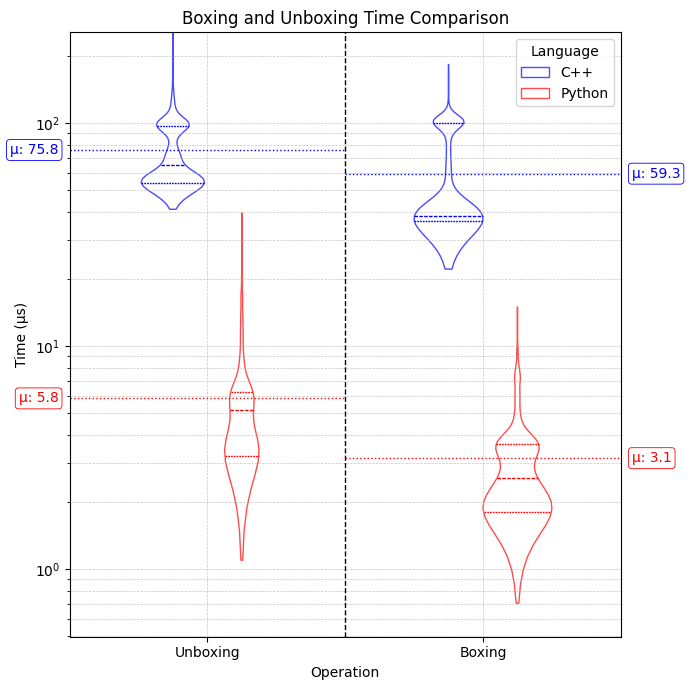

In [6]:
def draw_comparisons(cpp_timings, py_timings):

    # --- 1. build the tidy dataframe exactly as before ------------------------
    data = {
        "Time (µs)": np.concatenate([
            cpp_timings.unboxing[1:], cpp_timings.boxing[1:],
            py_timings.unboxing[1:],  py_timings.boxing[1:]
        ]),
        "Operation": (["Unboxing"] * (len(cpp_timings.unboxing) - 1)  +
                      ["Boxing"]   * (len(cpp_timings.boxing)  - 1)  +
                      ["Unboxing"] * (len(py_timings.unboxing) - 1)  +
                      ["Boxing"]   * (len(py_timings.boxing)   - 1)),
        "Language":  (["C++"] * ((len(cpp_timings.unboxing)-1) + (len(cpp_timings.boxing)-1)) +
                      ["Python"] * ((len(py_timings.unboxing)-1)  + (len(py_timings.boxing)-1)))
    }
    df = pd.DataFrame(data)

    # --- 2. violin plot --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.margins(x=0,y=0)
    sns.violinplot(
        x="Operation", y="Time (µs)", hue="Language", data=df,
        palette=["blue", "red"], fill=False, alpha=.7, width=0.5, linewidth=1, inner="quart", ax=ax
    )
    ax.set_yscale("log")
    ax.set_title("Boxing and Unboxing Time Comparison")
    ax.grid(True, which='both', ls='--', lw=0.5, alpha=0.7)

    # Draw the centre divider between the two categories
    mid = 0.5
    ax.axvline(mid, color='black', ls='--', lw=1)

    # --- 3. numeric averages ---------------------------------------------------
    means = {
        "cpp_unbox":  np.mean(cpp_timings.unboxing[1:]),
        "py_unbox":   np.mean(py_timings.unboxing[1:]),
        "cpp_box":    np.mean(cpp_timings.boxing[1:]),
        "py_box":     np.mean(py_timings.boxing[1:])
    }

    # --- 4. horizontal extents for each half ----------------------------------
    left_edge, right_edge = ax.get_xlim()   # typically (-0.5, 1.5)
    # left half spans [left_edge, mid]; right half spans [mid, right_edge]

    # --- 5. helper: draw one mean line + annotation ---------------------------
    def draw_mean(y, x0, x1, colour, text_side):
        
        """text_side: 'left' or 'right' for where to place the label box"""
        # dotted line
        ax.hlines(y, x0, x1, color=colour, ls='dotted', lw=1)

        # blended transform: x in *axes* fraction (0–1), y in *data* units
        trans = transforms.blended_transform_factory(ax.transAxes, ax.transData)

        if text_side == 'left':
            xp = -0.02      # a smidge left of the frame
            ha = 'right'
        else:               # 'right'
            xp = 1.02       # a smidge right of the frame
            ha = 'left'

        ax.text(
            xp, y, f"µ: {y:.1f}",
            transform=trans, ha=ha, va='center', color=colour,
            bbox=dict(boxstyle="round,pad=0.25", fc='white', ec=colour, lw=0.6),
            clip_on=False                          # let it sit outside the axes
        )

    # --- 6. draw all four ------------------------------------------------------
    draw_mean(means["cpp_unbox"], left_edge,  mid,  'blue',  'left')
    draw_mean(means["py_unbox"],  left_edge,  mid,  'red',   'left')
    draw_mean(means["cpp_box"],   mid, right_edge, 'blue',  'right')
    draw_mean(means["py_box"],    mid, right_edge, 'red',   'right')

    
    plt.tight_layout()
    plt.savefig(f"../paper/figures/boxing_unboxing_comparison.svg", format="svg", dpi=300)
    plt.show()
    

draw_comparisons(cpp_timings, py_timings)

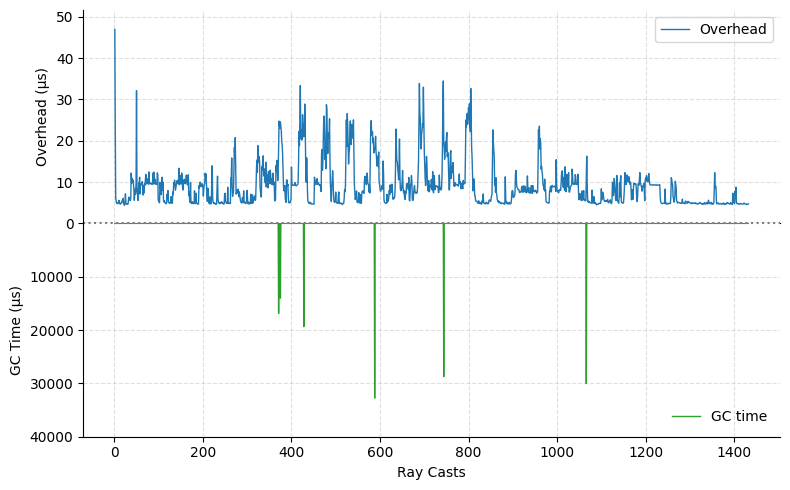

In [7]:
def draw_overhead_mirrored(py_timings):
    # 1) compute how many valid points each series has (we skip index 0)
    n_overhead = len(py_timings.overhead) - 1
    n_gc       = len(py_timings.gc_time)  - 1
    n = min(n_overhead, n_gc)

    # 2) build the step array 1..n
    steps = np.arange(1, n + 1)

    # 3) slice both series to exactly n points
    py_overhead = py_timings.overhead[1:1+n]
    py_gc       = py_timings.gc_time[1:1+n]

    # 4) find maxima for each for axis limits
    max_oh = py_overhead.max()
    max_gc = py_gc.max()

    # 5) set up two equal‐height subplots sharing x
    fig = plt.figure(figsize=(8, 5))
    gs  = fig.add_gridspec(2, 1, height_ratios=[1,1], hspace=0)
    
    ax_top = fig.add_subplot(gs[0])
    ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

    # --- Top: Python overhead (grows upward) ---
    sns.lineplot(x=steps, y=py_overhead,
                 ax=ax_top, color="C0", linewidth=1,
                 label="Overhead")
    ax_top.set_ylim(0, max_oh * 1.1)
    ax_top.spines['bottom'].set_visible(False)
    ax_top.tick_params(labelbottom=False)
    ax_top.set_ylabel("Overhead (µs)")
    ax_top.grid(True, linestyle='--', alpha=0.4)

    # --- Bottom: Python GC (grows downward) ---
    sns.lineplot(x=steps, y=py_gc,
                 ax=ax_bot, color="C2", linewidth=1,
                 label="GC time")
    ax_bot.set_ylim(max_gc * 1.1, 0)   # invert limits instead of invert_yaxis
    ax_bot.spines['top'].set_visible(False)
    ax_bot.set_ylabel("GC Time (µs)")
    ax_bot.set_xlabel("Ray Casts")
    ax_bot.grid(True, linestyle='--', alpha=0.4)

    # --- shared baseline line at zero for both ---
    ax_top.axhline(0, color="gray", linestyle="dotted")
    ax_bot.axhline(0, color="gray", linestyle="dotted")
    
    yticks = ax_bot.get_yticks()
    ax_bot.set_yticks([yt for yt in yticks if yt != 0])

    # --- legend on bottom only ---
    ax_bot.legend(loc="lower right", frameon=False)

    # --- despine and layout ---
    sns.despine(fig=fig, left=False, bottom=False)
    plt.tight_layout()
    
    plt.savefig(f"../paper/figures/overhead_mirrored.svg", format="svg", dpi=300)
    plt.show()

# Usage
draw_overhead_mirrored(py_timings)

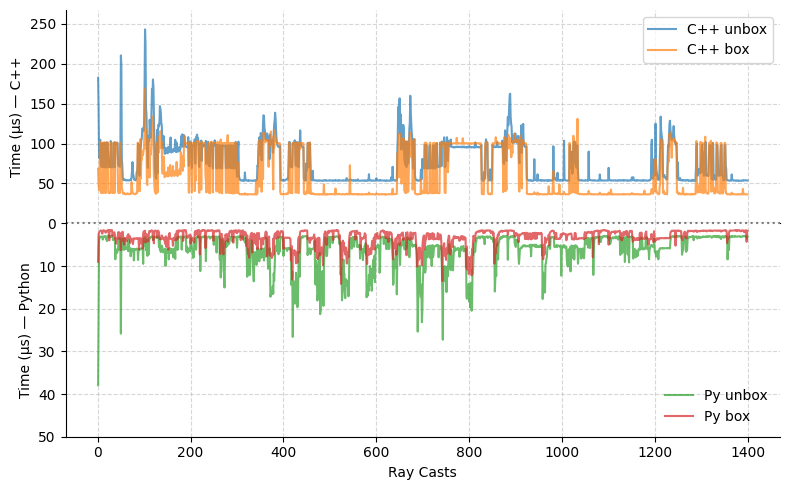

In [8]:
def draw_overhead_mirrored(py_timings, cpp_timings):
    # 1) trim to common length
    min_len = min(
        len(cpp_timings.unboxing[1:]),
        len(cpp_timings.boxing[1:]),
        len(py_timings.unboxing[1:]),
        len(py_timings.boxing[1:])
    )
    steps = np.arange(1, min_len + 1)

    # 2) extract
    cpp_unbox = cpp_timings.unboxing[1:1+min_len]
    cpp_box   = cpp_timings.boxing[1:1+min_len]
    
    py_unbox  = py_timings.unboxing[1:1+min_len]
    py_box    = py_timings.boxing[1:1+min_len]

    # 3) compute maxima for axis limits
    top_max    = max(cpp_unbox.max(), cpp_box.max())
    bottom_max = max(py_unbox.max(), py_box.max())

    # 4) build figure with two equally-tall subplots
    fig = plt.figure(figsize=(8,5))
    gs  = fig.add_gridspec(2, 1, height_ratios=[1,1], hspace=0)

    ax_top = fig.add_subplot(gs[0])
    ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

    # 5) plot C++ (positive) on top
    sns.lineplot(x=steps, y=cpp_unbox, ax=ax_top, label="C++ unbox", color="C0", alpha=0.7)
    sns.lineplot(x=steps, y=cpp_box,   ax=ax_top, label="C++ box",   color="C1", alpha=0.7)
    ax_top.set_ylim(0, top_max * 1.1)
    ax_top.spines['bottom'].set_visible(False)
    ax_top.tick_params(labelbottom=False)  # hide x labels up top
    ax_top.grid(True, linestyle='--', alpha=0.5)

    # 6) plot Python (positive) on bottom, then invert
    sns.lineplot(x=steps, y=py_unbox,  ax=ax_bot, label="Py unbox",  color="C2", alpha=0.7)
    sns.lineplot(x=steps, y=py_box,    ax=ax_bot, label="Py box",    color="C3", alpha=0.7)
    ax_bot.set_ylim(0, bottom_max * 1.1)
    ax_bot.invert_yaxis()               # so it grows “down”
    ax_bot.spines['top'].set_visible(False)

    yticks = ax_bot.get_yticks()
    ax_bot.set_yticks([yt for yt in yticks if yt != 0])

    # 7) draw a “baseline” at the shared boundary
    ax_top.axhline(0, color="gray", linestyle="dotted")
    ax_bot.axhline(0, color="gray", linestyle="dotted")

    # 8) labels & legend
    ax_bot.set_xlabel("Ray Casts")
    ax_top.set_ylabel("Time (µs) — C++")
    ax_bot.set_ylabel("Time (µs) — Python")
    ax_bot.legend(loc="lower right", frameon=False)
    ax_bot.grid(True, linestyle='--', alpha=0.5)

    sns.despine(fig=fig, left=False, bottom=False)
    plt.tight_layout()
    
    plt.savefig(f"../paper/figures/boxing_unboxing_mirrored.svg", format="svg", dpi=300)
    plt.show()


draw_overhead_mirrored(py_timings, cpp_timings)

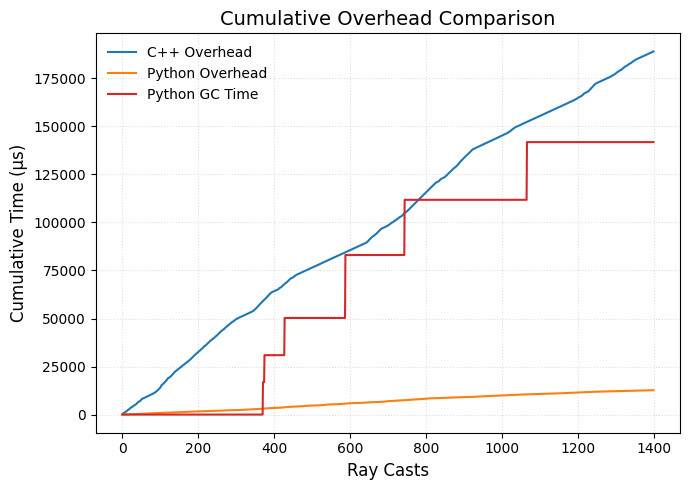

In [9]:
from statsmodels.nonparametric.smoothers_lowess import lowess

def draw_cumulative_overhead(py_timings, cpp_timings):
    # 1) figure out how many points both series share
    #    (we skip index 0 in overhead to match your intent)
    len_py  = len(py_timings.overhead) - 1
    len_cpp = len(cpp_timings.overhead) - 1
    n = min(len_py, len_cpp)

    # 2) steps 1..n
    steps = np.arange(1, n + 1)

    # 3) cumulative sums up to n
    py_cum  = np.cumsum(py_timings.overhead[1:1+n])
    cpp_cum = np.cumsum(cpp_timings.overhead[1:1+n])
    py_gc_cum = np.cumsum(py_timings.gc_time[1:1+n])

    # 4) plot
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.lineplot(x=steps, y=cpp_cum, label="C++ Overhead", color="C0", ax=ax)
    sns.lineplot(x=steps, y=py_cum,  label="Python Overhead", color="C1", ax=ax)
    sns.lineplot(x=steps, y=py_gc_cum, label="Python GC Time", color="C3", ax=ax)

    # 5) labels & grid
    ax.set_title("Cumulative Overhead Comparison", fontsize=14)
    ax.set_xlabel("Ray Casts", fontsize=12)
    ax.set_ylabel("Cumulative Time (µs)", fontsize=12)
    ax.legend(frameon=False)
    ax.grid(True, linestyle=":", alpha=0.4)

    plt.tight_layout()
    
    plt.savefig(f"../paper/figures/cumulative_overhead.svg", format="svg", dpi=300)
    plt.show()
    
draw_cumulative_overhead(py_timings, cpp_timings)

In [10]:
calculate_metrics(
    cpp_timings.unboxing[1:], 
    cpp_timings.boxing[1:], 
    cpp_timings.actual[1:], 
    cpp_timings.overhead[1:], 
    "cpp"
)

calculate_metrics(
    py_timings.unboxing[1:], 
    py_timings.boxing[1:], 
    py_timings.actual[1:], 
    py_timings.overhead[1:], 
    "python"
)

NameError: name 'calculate_metrics' is not defined